In [1]:
import cogent3
from cogent3 import get_app
from cogent3.maths.matrix_exponential_integration import expected_number_subs
import matplotlib.pyplot as plt
import paths
import libs
import pandas as pd
import numpy as np

chromosomes = list(range(1, 23))

In [2]:
#delete next line on final analysis
chromosomes = list(range(1, 5))
chromosome_lengths = [247249719, 242951149, 199501827, 191273063]
sampled_size = sum(chromosome_lengths)
total_size = 6045293052
relative_sample_length = sampled_size/total_size

## Intergenic Ancestral Repeats (IGAR)

In [3]:
total_length_IGAR=0

for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'intergenicAR/chrm' + str(chrom_coord) + '/'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')
    
    #loading and cocatanating sequences
    #rename_noncds eliminates files that do not contain Gorilla, Human and Chimp sequences or that has duplicates.
    loader = get_app("load_aligned", moltype="dna")
    omit_degs_noncds = get_app("omit_degenerates", moltype="dna")
    rename_noncds = libs.renamer_noncds_aligned()
    seq_length = libs.human_seq_length()
    
    noncds_app = loader + omit_degs_noncds + rename_noncds + seq_length
    
    seq_lengths = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_IGAR = total_length_IGAR + temp_length

#delete next line on final analysis
total_length_IGAR = (1/relative_sample_length)*total_length_IGAR

   0%|          |00:00<?

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

## CDS

In [4]:
total_length_cds=0

#delete next line on final analysis
chromosomes = [15, 22, 3]
for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'cds/chrm' + str(chrom_coord) + '/codon_aligned'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')
    
    loader_cds = get_app("load_aligned", moltype="dna")   
    omit_degs_cds = get_app("omit_degenerates", moltype="dna", motif_length=3)
    seq_length_cds = libs.human_seq_length()
    
    cds_process = loader_cds + omit_degs_cds + seq_length_cds
    
    seq_lengths = [r for r in cds_process.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_cds = total_length_cds + temp_length

#delete next line on final analysis
relative_cdssample_length = (100338915 + 49691432 + 199501827)/total_size
total_length_cds = (1/relative_cdssample_length)*total_length_cds

   0%|          |00:00<?

   0%|          |00:00<?

   0%|          |00:00<?

In [5]:
#delete next line on final analysis
chromosomes = list(range(1, 5))
chromosome_lengths = [247249719, 242951149, 199501827, 191273063]
sampled_size = sum(chromosome_lengths)
total_size = 6045293052
relative_sample_length = sampled_size/total_size

## Introns

In [6]:
total_length_introns=0
for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'introns/chrm' + str(chrom_coord) + '/noUTRs/'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')
    
    #loading sequences that had been renamed already
    loader_renamed = get_app("load_aligned", moltype="dna")
    omit_degs_noncds_renamed = get_app("omit_degenerates", moltype="dna")
    seq_length_renamed = libs.human_seq_length()
    
    noncds_renamed_app = loader_renamed + omit_degs_noncds_renamed + seq_length_renamed
    
    seq_lengths = [r for r in noncds_renamed_app.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_introns = total_length_introns + temp_length

#delete next line on final analysis
total_length_introns = (1/relative_sample_length)*total_length_introns

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

## 5' UTR

In [7]:
total_length_5UTR=0
for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'introns/chrm' + str(chrom_coord) + '/5UTR/'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

    #loading sequences that had been renamed already
    seq_lengths = [r for r in noncds_renamed_app.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_5UTR = total_length_5UTR + temp_length

#delete next line on final analysis
total_length_5UTR = (1/relative_sample_length)*total_length_5UTR

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

## 3' UTR

In [8]:
total_length_3UTR=0
for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'introns/chrm' + str(chrom_coord) + '/3UTR/'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

    #loading sequences that had been renamed already
    seq_lengths = [r for r in noncds_renamed_app.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_3UTR = total_length_3UTR + temp_length

#delete next line on final analysis
total_length_3UTR = (1/relative_sample_length)*total_length_3UTR

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

## Introns Ancestral Repeats (IntronAR)

In [9]:
total_length_intronAR = 0
for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'intronsAR/chrm' + str(chrom_coord) + '/'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')
    
    seq_lengths = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_intronAR = total_length_intronAR + temp_length

#delete next line on final analysis
total_length_intronAR = (1/relative_sample_length)*total_length_intronAR

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

## Intergenic distal (5kb distal from transcript)

In [10]:
total_length_distalIG = 0
for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'distal_IG/chrm' + str(chrom_coord) + '/'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')
    
    seq_lengths = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_distalIG = total_length_distalIG + temp_length

#delete next line on final analysis
total_length_distalIG = (1/relative_sample_length)*total_length_distalIG

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

## Intergenic proximal 5' (5kb proximal from transcript start)

In [11]:
total_length_proximal5IG=0
for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'proximal5_IG/chrm' + str(chrom_coord) + '/'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')
    
    seq_lengths = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_proximal5IG = temp_length + total_length_proximal5IG

#delete next line on final analysis
total_length_proximal5IG = (1/relative_sample_length)*total_length_proximal5IG

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

In [12]:
total_length_proximal5IG

76846208.72084804

## Intergenic proximal 3' (5kb proximal from transcript end)

In [13]:
total_length_proximal3IG = 0
for chrom_coord in chromosomes:
    folder_in = paths.DATA_APES114 + 'proximal3_IG/chrm' + str(chrom_coord) + '/'
    in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')
    
    seq_lengths = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
    
    values = [x.obj for x in seq_lengths]
    temp_length = sum(values)
    total_length_proximal3IG = total_length_proximal3IG + temp_length

#delete next line on final analysis
total_length_proximal3IG = (1/relative_sample_length)*total_length_proximal3IG

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f94b4962840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
    self.notify_chang

Text(0, 0.5, 'Haploid sequence length')

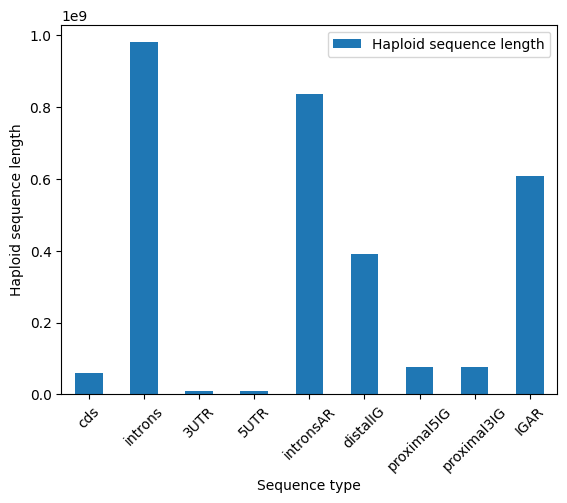

In [14]:
Length_data = pd.DataFrame([
        ['cds', total_length_cds],
        ['introns', total_length_introns],
        ['3UTR', total_length_3UTR],
        ['5UTR', total_length_5UTR],
        ['intronsAR', total_length_intronAR],
        ['distalIG', total_length_distalIG],
        ['proximal5IG', total_length_proximal5IG],
        ['proximal3IG', total_length_proximal3IG],
        ['IGAR', total_length_IGAR],
    ],
    columns = ['Sequence type', 'Haploid sequence length'])

Length_data.plot(
    x='Sequence type',
    kind = 'bar',
    rot=45)
plt.ylabel('Haploid sequence length')

In [15]:
Length_data.to_csv("Output_data/number_sites_perregion.csv", index=False)
Length_data

,Sequence type,Haploid sequence length
0,cds,5.820723e+07
1,introns,9.803886e+08
2,3UTR,9.429208e+06
3,5UTR,9.669105e+06
4,intronsAR,8.373507e+08
5,distalIG,3.914073e+08
6,proximal5IG,7.684621e+07
7,proximal3IG,7.698751e+07
8,IGAR,6.092450e+08


In [16]:
Total_length = sum(Length_data["Haploid sequence length"])
print(Total_length)
print(Total_length/1000000)

3049530854.790026
3049.5308547900263
